# 1. Problema Preditivo

Este projeto tem como objetivo prever a variável **cognitive_performance_score**, que representa o desempenho cognitivo do indivíduo no dia seguinte, com base em informações relacionadas à qualidade do sono, hábitos de vida, indicadores fisiológicos e fatores comportamentais. 

Essa previsão é relevante para apoiar a identificação antecipada de fatores que impactam o desempenho cognitivo, possibilitando a adoção de estratégias para melhorar a qualidade do sono, o bem-estar e a produtividade, além de subsidiar decisões em contextos de saúde, pesquisa e desenvolvimento de soluções voltadas ao monitoramento da saúde do sono.

# 2. Diretório Principal

In [1]:
import sys
from pathlib import Path


# Diretório atual
PROJECT_ROOT = Path.cwd() 

# Sobe um diretório por vez até encontrar a pasta ˜src˜.
while not (PROJECT_ROOT / "src").exists(): 
    PROJECT_ROOT = PROJECT_ROOT.parent  

# Se a pasta principal do projeto ainda não está na lista de locais onde se procura módulos, add
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# 3. Carregando o Dataset

In [2]:
from src.dataset import carregar_dataset

df = carregar_dataset()
df.head(5)

Dataset carregado: 100000 linhas x 32 colunas


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# 4. Fase 1: Análise Exploratória de Dados (EDA)

## 4.1. Estatística Descritiva

In [3]:
from src.eda import estatistica_descritiva

estatistica_descritiva(df)#

DIMENSÕES DO DATASET
Linhas : 100000
Colunas: 32


TIPOS DAS VARIÁVEIS
person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                  

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,0.596800,63.539620,0.450710,7496.859740,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,1.059161,44.550502,0.497567,3460.423881,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,500.000000,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,0.000000,30.000000,0.000000,5045.000000,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,0.000000,51.000000,0.000000,7442.000000,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,1.000000,84.000000,1.000000,9887.000000,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,6.000000,180.000000,1.000000,20000.000000,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


Os tipos de dados estão coerentes com seus respectivos valores.

A análise estatística descritiva mostra que o conjunto de dados possui 100.000 observações completas, sem valores ausentes nas variáveis numéricas. A variável-alvo (**cognitive_performance_score**) possui média de 59,23 e mediana de 60,40, sugerindo uma distribuição aproximadamente simétrica, hipótese que será confirmada posteriormente por meio do histograma.

## 4.2. Visualização de Dados

Assimetria da variável-alvo: -0.29
Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/distribuicao_variavel_alvo.png


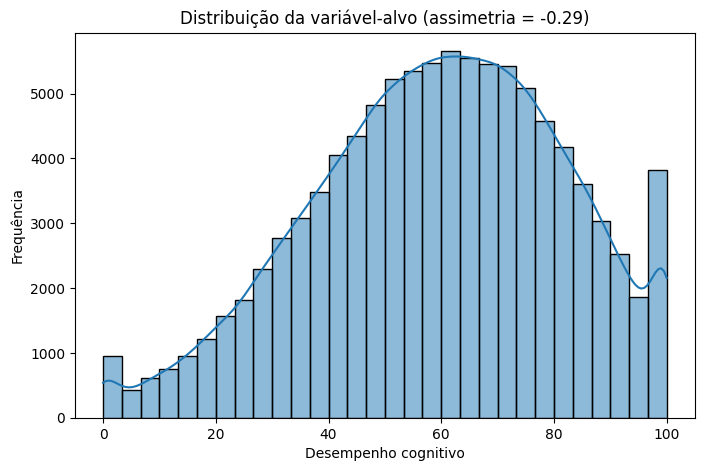

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/qualidade_sono_desempenho.png


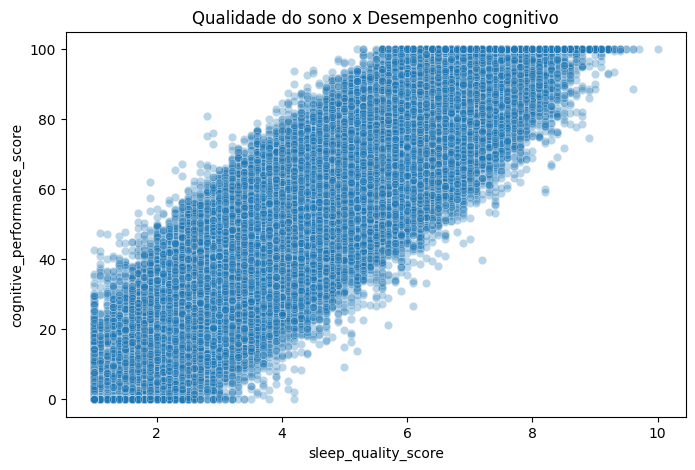

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/estresse_desempenho.png


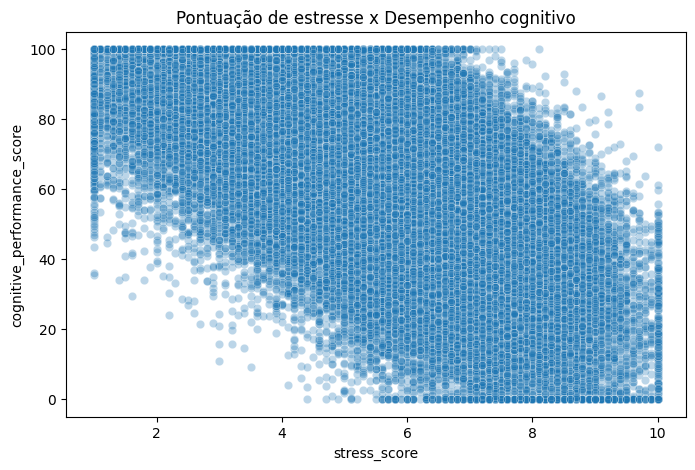

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/correlacao_pearson.png


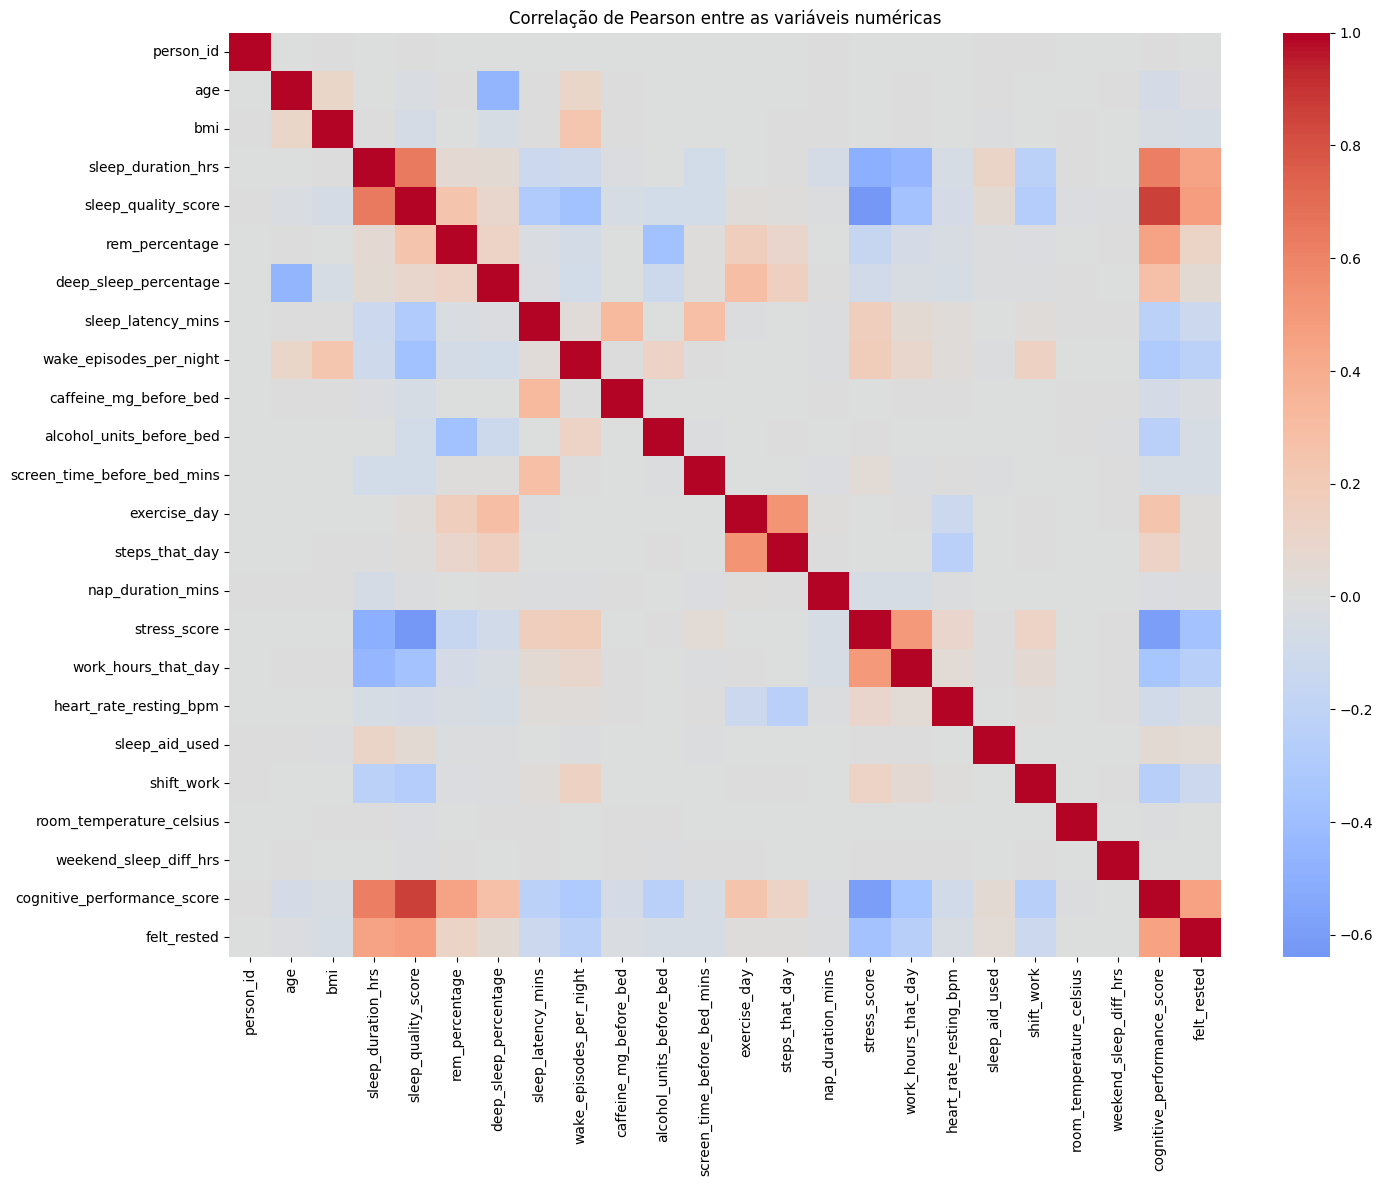

Pares com correlação > 0.7:
sleep_quality_score  cognitive_performance_score    0.859978
dtype: float64


In [4]:
from src.eda import visualizar_dados

visualizar_dados(df)

### Histograma de distribuição da variável-alvo

A variável-alvo apresenta distribuição aproximadamente simétrica, com leve assimetria negativa (−0,29), concentrando a maior parte dos valores entre 50 e 80 pontos. Essa característica é favorável para modelos de regressão.

---

### Gráficos de dispersão entre variáveis explicativas e a variável-alvo

**Qualidade do sono × Desempenho cognitivo:** relação positiva, indicando que maiores valores de qualidade do sono tendem a estar associados a um melhor desempenho cognitivo.

**Estresse × Desempenho cognitivo:** relação negativa, sugerindo que maiores níveis de estresse tendem a estar associados a um menor desempenho cognitivo.

---

### Mapa de calor da correlação de Pearson

O mapa de calor evidencia que a variável-alvo apresenta correlação positiva principalmente com a qualidade (muito forte -> 0,85) e a duração do sono, e correlação negativa com o estresse e as horas de trabalho. Além disso, as variáveis explicativas apresentam, em geral, correlações de baixa a moderada intensidade, não sendo observados indícios de multicolinearidade significativa.

# 5. Fase 2: Tratamento e Limpeza (Data Prep)

## 5.1. Linhas Duplicadas

In [5]:
from src.preprocessing import verificar_duplicados

verificar_duplicados(df)

VERIFICAÇÃO DE DUPLICADOS
Registros duplicados: 0


np.int64(0)

Não há registros duplicados. Logo, não há necessidade de tratá-los.

## 5.2. Valores Ausentes (Missing Data)

In [6]:
from src.preprocessing import verificar_valores_ausentes

verificar_valores_ausentes(df)

VERIFICAÇÃO DE VALORES AUSENTES
Não há valores ausentes no conjunto de dados.


,Valores Ausentes,Percentual (%)


Não há valores ausentes. Logo, não há necessidade de tratá-los.

## 5.3. Remoção de Colunas

In [7]:
from src.preprocessing import remover_colunas

df = remover_colunas(df, ["person_id"])

df.head(5)

Colunas removidas: person_id


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


Removido coluna **person_id** pois ela não contribui para o resultado final.

## 5.4. Gerenciamento de Outliers

Gráfico salvo em: /Users/jenifer/Documents/SCTEC-PROJETO-MD1/outputs/figures/boxplots_variaveis_explicativas.png


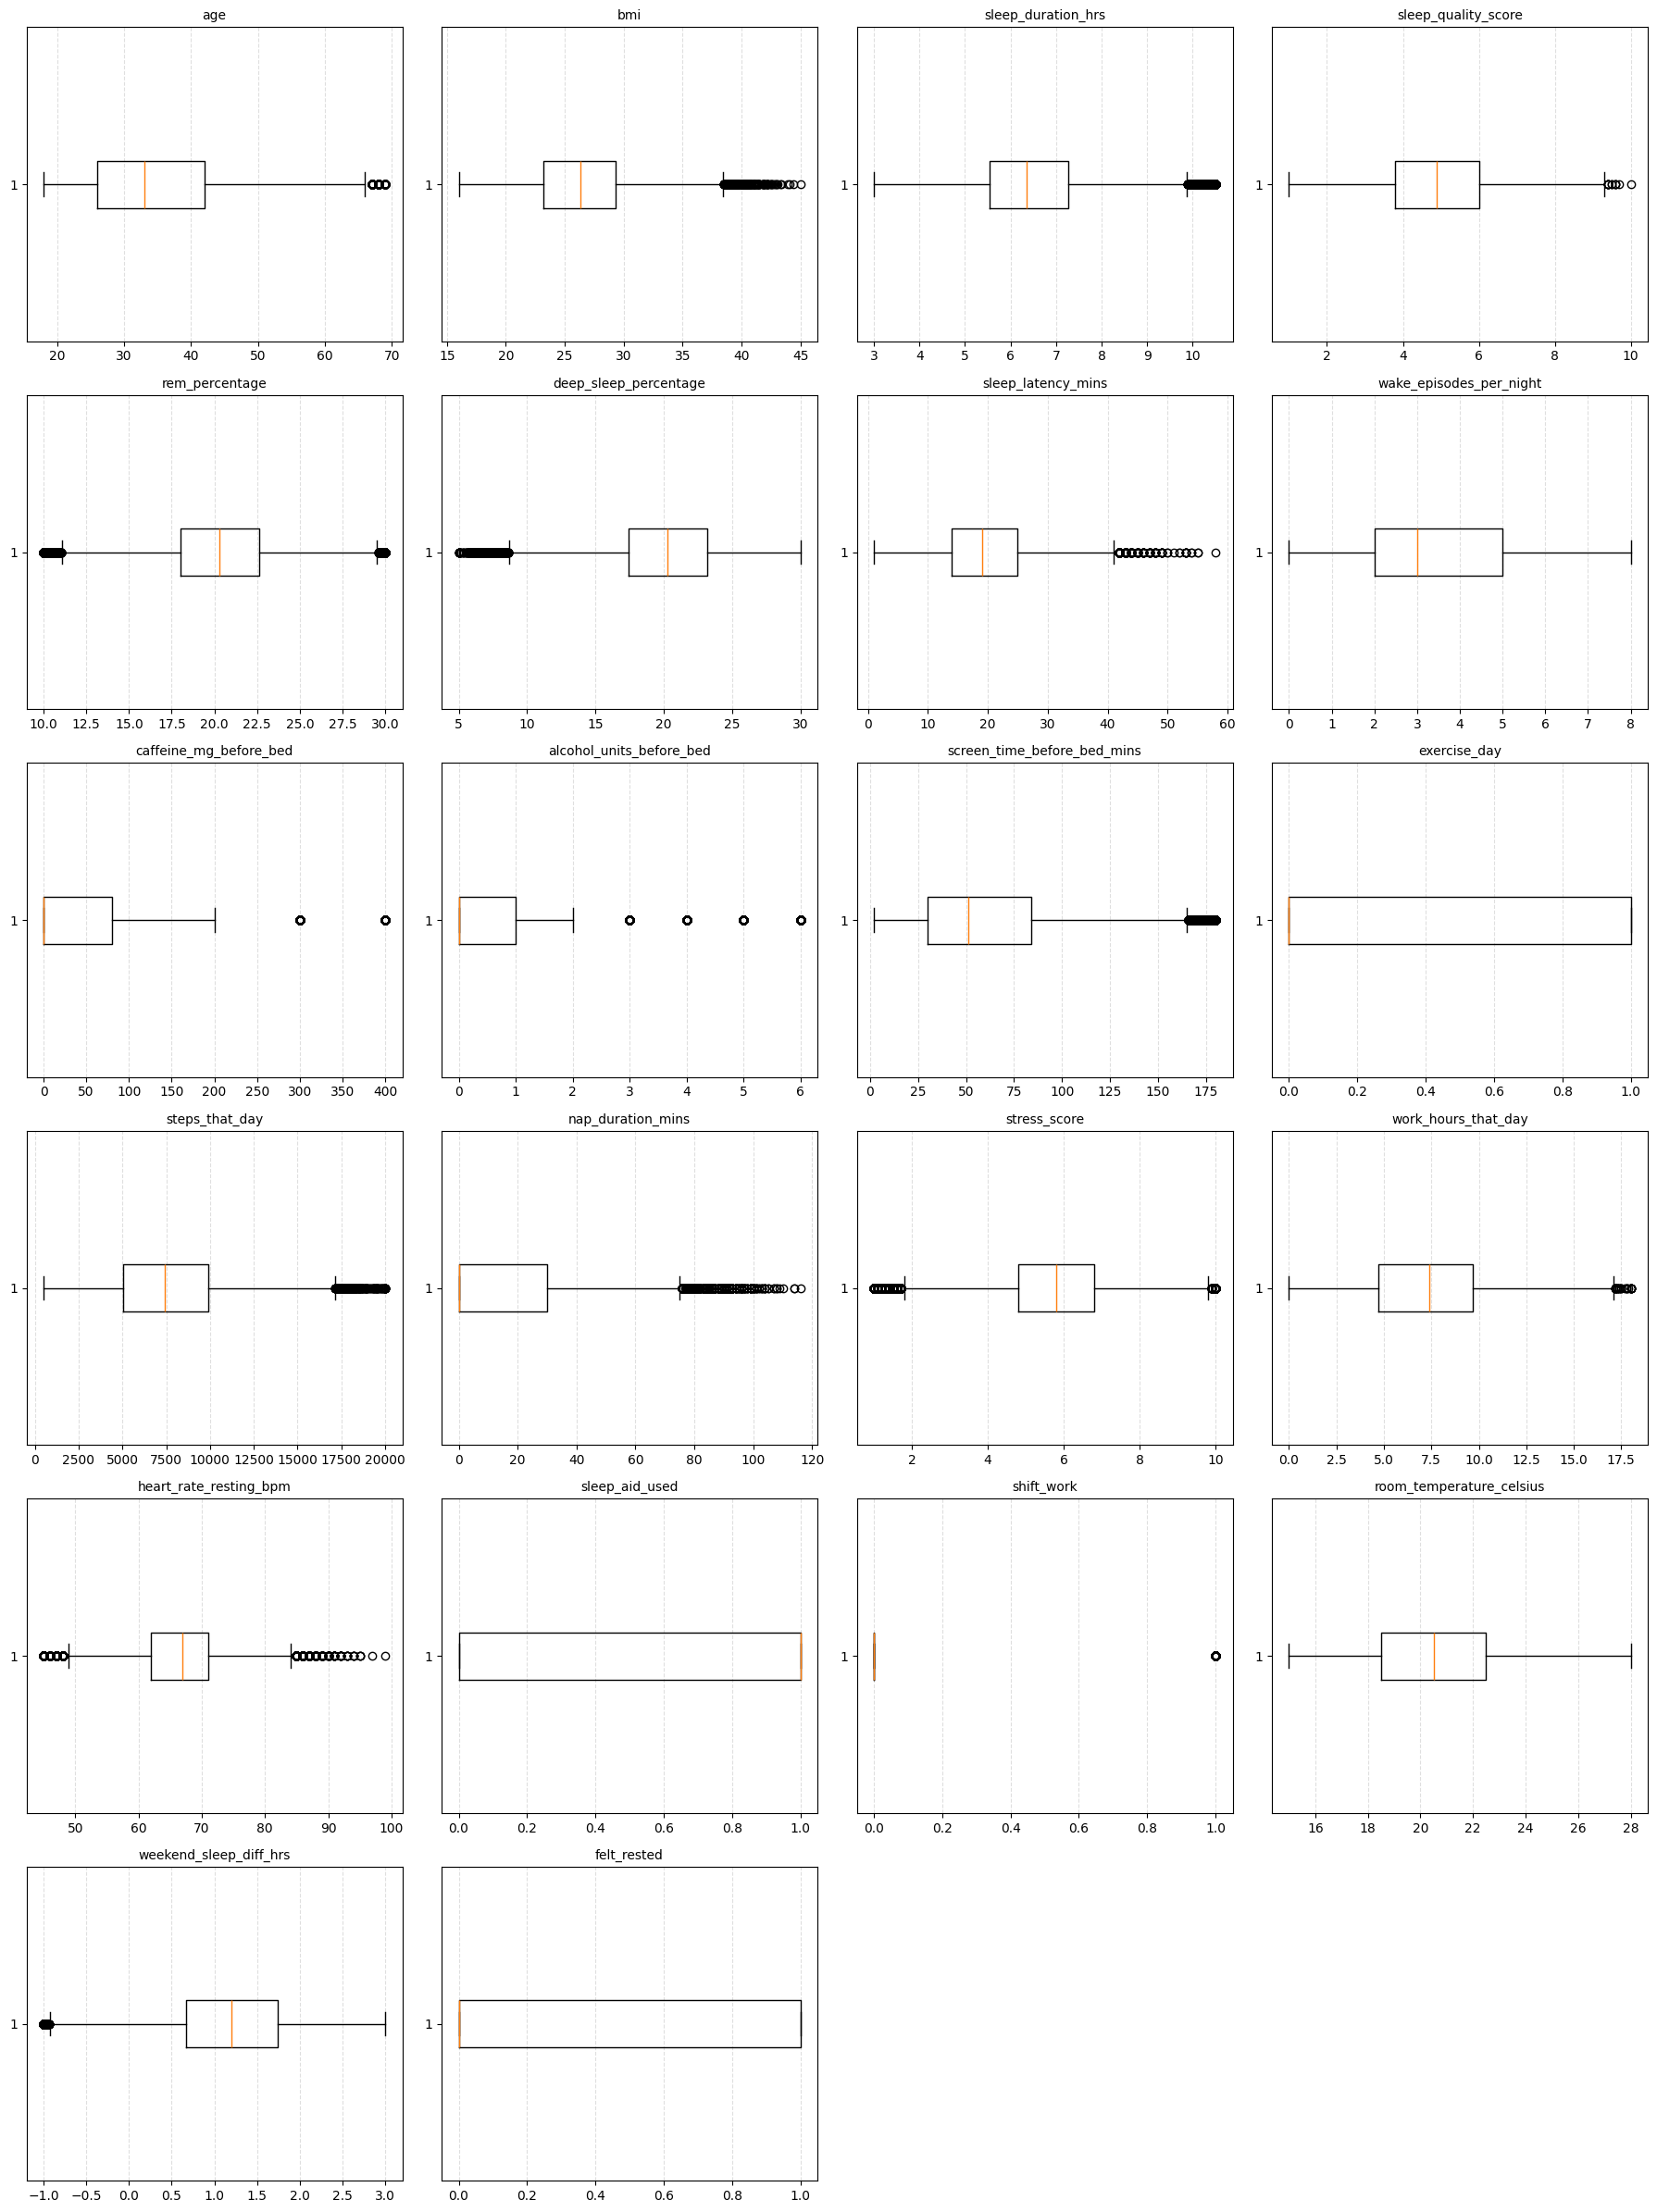

In [8]:
from src.preprocessing import plotar_boxplots

plotar_boxplots(df, variavel_alvo="cognitive_performance_score")